In [ ]:
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np

**Setup configuration**

In [12]:
cfg = get_cfg()

cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

cfg.MODEL.DEVICE = "cpu"

**Create predictor**

In [13]:
predictor = DefaultPredictor(cfg)

model_final_f10217.pkl: 178MB [00:03, 49.3MB/s]                              


In [ ]:
img_url = "http://images.cocodataset.org/val2017/000000439715.jpg"

resp = urllib.request.urlopen(img_url)
image = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image, cv2.IMREAD_COLOR)

print(image.shape)

(480, 640, 3)


**Run inference**

In [21]:
outputs = predictor(image)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0227 05:09:04.384000 500 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


**Access results**

In [22]:
instances = outputs['instances']
boxes = instances.pred_boxes
scores = instances.scores
classes = instances.pred_classes
masks = instances.pred_masks

print(f"Detected {len(instances)} objects")

Detected 15 objects


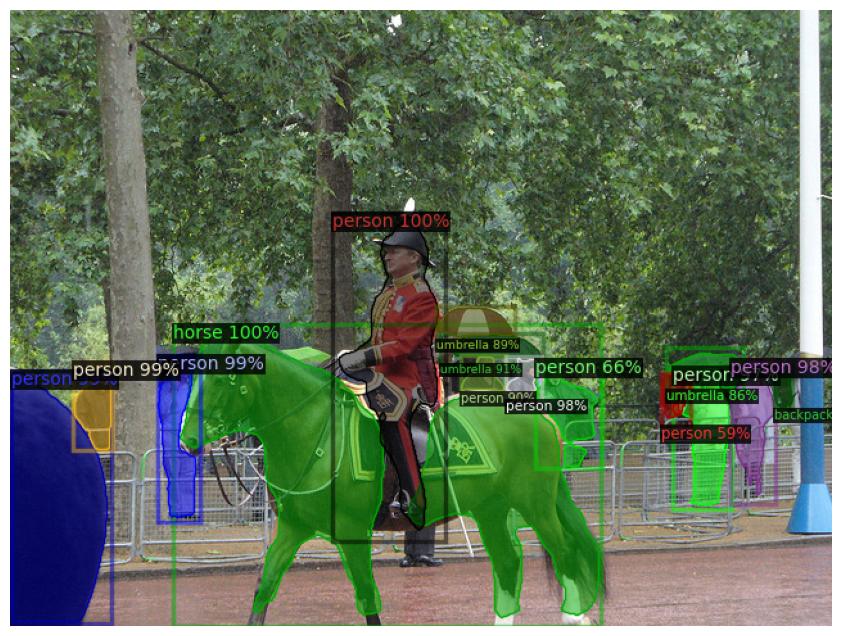

In [ ]:
instances = outputs["instances"].to("cpu")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])

v = Visualizer(
    image_rgb,
    metadata=metadata,
    scale=1.0,
    instance_mode=ColorMode.IMAGE
)


out = v.draw_instance_predictions(instances)
plt.figure(figsize=(12, 8))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()